# GOLDEN 09_seeded_causal

**Thesis section:** `sec:results:seeded`  
**Provenance:** Seeded Initial-Condition causal experiment. Ported verbatim from scripts/build_nb_036.py (superseded).  
**Data:** results/mas/initial_position/seeded_init_{0,1,2,3}  
**Figures exported to:** thesis/plots/highrep/ (fig4_seeded_causal .. fig7_recovery_difficulty)  
**Status:** reproducible from committed data.

This is a GOLDEN notebook: it recomputes every number in the named thesis section from raw data and exports every figure to the fixed `thesis/plots/` path the LaTeX already includes. Numbers are printed in labelled blocks for manual copy into the thesis. See `notebooks/golden/INDEX.md` for the full section->notebook map.

# 036 — Seeded Initial-Condition Analysis (causal dose-response)

The R=1000 high-repetition analysis (nb 031) established *observationally* that
whether the ground-truth (GT) option is present in the initial vote distribution
is the dominant predictor of final accuracy. That is a correlation: initial
composition co-varies with task difficulty, agent confidence, and everything else.

This notebook analyses a **controlled intervention** that fixes the initial vote
composition directly, holding everything else at the real debate dynamics across
four conditions:

- **seeded_init_0**: exactly **0** of 4 agents start on the correct answer (GT absent).
- **seeded_init_1**: exactly **1** of 4 agents starts on the correct answer (1/4 minority).
- **seeded_init_2**: exactly **2** of 4 agents start on the correct answer (2/4 tie).
- **seeded_init_3**: exactly **3** of 4 agents start on the correct answer (3/4 majority).

The wrong votes are drawn from a pool of genuine independent agent responses to the
same task, so only the *initial composition* is manipulated; the debate itself is
real. The four conditions form a dose-response curve that isolates the causal effect
of initial GT-presence on final accuracy.

50 GPQA tasks, $R=50$ each ($W=2$, FC, $N=4$).

Figures exported to `thesis/plots/highrep/`.

In [ ]:
import sys
sys.path.insert(0, '../..')

import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import (chi2_contingency, wilcoxon, mannwhitneyu,
                         pearsonr, spearmanr, entropy as scipy_entropy)
import statsmodels.api as sm

BASE        = Path('../..') / 'results' / 'mas'
SEEDED_BASE = BASE / 'initial_position'
EXPORT      = Path('../..') / 'thesis'  / 'plots' / 'highrep'
EXPORT.mkdir(parents=True, exist_ok=True)

C0    = '#7F7F7F'   # init_0  (GT absent)
C1    = '#0072B2'   # init_1  (1/4 correct)
C2    = '#009E73'   # init_2  (2/4 correct)
C3    = '#E69F00'   # init_3  (3/4 correct)
COLORS = [C0, C1, C2, C3]
CACC  = '#D55E00'

from src.viz.thesis_style import apply_style, no_grid
apply_style()
print('setup ok')

In [ ]:
def wilson_ci(k, n, z=1.96):
    if n == 0: return (0.0, 0.0)
    p = k / n; denom = 1 + z**2/n
    centre = (p + z**2/(2*n)) / denom
    half = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return float(max(0, centre-half)), float(min(1, centre+half))

def load_condition(cond):
    out = {}
    for f in sorted((SEEDED_BASE / f'seeded_init_{cond}').glob('*.json')):
        d = json.loads(f.read_text())
        out[str(d['question_id'])] = d
    return out

def vote_profile(rep, t):
    return [ag['vote'] for ag in rep['trajectory'][t]['phase_b']]

def gt_share_trajectory(rep, gt):
    return [vote_profile(rep, t).count(gt) / rep['N']
            for t in range(len(rep['trajectory']))]

d0 = load_condition(0)
d1 = load_condition(1)
d2 = load_condition(2)
d3 = load_condition(3)
ALL_D = [d0, d1, d2, d3]

COMMON = sorted(set(d0) & set(d1) & set(d2) & set(d3), key=int)
print(f'tasks per condition: {[len(d) for d in ALL_D]}  common={len(COMMON)}')
for i, d in enumerate(ALL_D):
    only = sorted(set(d) - set(COMMON), key=int)
    if only: print(f'  only in init_{i}:', only)

In [ ]:
def build_rows(dd, cond):
    rows = []
    for q in COMMON:
        d = dd[q]; gt = d['ground_truth']; opts = list(d['options'].keys())
        for r in d['repetitions']:
            b0 = r['trajectory'][0]['phase_b']
            v0 = [ag['vote'] for ag in b0]
            vf = vote_profile(r, -1)
            wrong0 = [v for v in v0 if v != gt]
            opp_top = max(Counter(wrong0).values()) if wrong0 else 0
            conf_gt = np.mean([ag['confidence'] for ag in b0 if ag['vote'] == gt]) if gt in v0 else np.nan
            conf_wr = np.mean([ag['confidence'] for ag in b0 if ag['vote'] != gt]) if wrong0 else np.nan
            sh = gt_share_trajectory(r, gt)
            gt_first = next((i for i, s in enumerate(sh) if s > 0), -1)
            rows.append({
                'cond': cond, 'qid': q, 'gt': gt,
                'n_correct_pool': d['n_correct_pool'],
                'correct': int(r['correct']),
                'rounds': len(r['trajectory']) - 1,
                'final_unanimous': int(len(set(vf)) == 1),
                'gt_final_share': sh[-1],
                'opp_top_bloc': opp_top,
                'conf_advantage': (conf_gt - conf_wr) if not np.isnan(conf_gt) else np.nan,
                'gt_first_round': gt_first,
            })
    return pd.DataFrame(rows)

dfs = [build_rows(d, i) for i, d in enumerate(ALL_D)]
df0, df1, df2, df3 = dfs
df = pd.concat(dfs, ignore_index=True)
for i, d in enumerate(dfs):
    print(f'cond={i}: rows={len(d)}  unanimity={d["final_unanimous"].mean():.3f}')

## 1. Core causal result

Pooled and per-task accuracy under the two seeding conditions, and the paired
across-task test.


In [ ]:
ks = [d['correct'].sum() for d in dfs]
ns = [len(d) for d in dfs]
accs_pooled = [k/n for k, n in zip(ks, ns)]
LABELS = ['init_0\n(GT absent)', 'init_1\n(1/4)', 'init_2\n(2/4)', 'init_3\n(3/4)']

print('=== Pooled accuracy per condition ===')
for i, (k, n, a) in enumerate(zip(ks, ns, accs_pooled)):
    ci = wilson_ci(k, n)
    print(f'  cond={i}: {k}/{n} = {a:.4f}  CI={tuple(round(x,4) for x in ci)}')

# pairwise chi2 vs cond=0
print('\n=== Chi2 vs baseline (init_0) ===')
k0, n0 = ks[0], ns[0]
for i in range(1, 4):
    ct = np.array([[ks[i], ns[i]-ks[i]], [k0, n0-k0]])
    chi2, p, _, _ = chi2_contingency(ct)
    print(f'  init_{i} vs init_0: chi2={chi2:.1f}  p={p:.2e}  lift={accs_pooled[i]/accs_pooled[0]:.1f}x')

# paired Wilcoxon per-task (all conditions vs init_0)
print('\n=== Paired Wilcoxon per task (vs init_0) ===')
a_per_task = [d.groupby('qid')['correct'].mean().reindex(COMMON) for d in dfs]
for i in range(1, 4):
    w, pw = wilcoxon(a_per_task[i].values, a_per_task[0].values)
    n_better = (a_per_task[i].values > a_per_task[0].values).sum()
    print(f'  init_{i} > init_0 in {n_better}/{len(COMMON)} tasks  W={w:.0f}  p={pw:.2e}  '
          f'median lift={np.median(a_per_task[i].values - a_per_task[0].values):.3f}')

k0, n0 = ks[0], ns[0]
k1, n1 = ks[1], ns[1]
ct01 = np.array([[k1, n1-k1],[k0, n0-k0]])
chi2_01, p01, _, _ = chi2_contingency(ct01)
w01, pw01 = wilcoxon(a_per_task[1].values, a_per_task[0].values)

n_denovo_tasks = int((a_per_task[0] > 0).sum())
print(f'\ninit_0: >=1 correct run in {n_denovo_tasks}/{len(COMMON)} tasks (de-novo recovery possible but rare)')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- (a) per-task trajectory lines across 4 conditions ---
ax = axes[0]
x = np.arange(4)
task_accs = np.array([a_per_task[c].reindex(COMMON).values for c in range(4)])  # (4, n_tasks)
for t in range(len(COMMON)):
    ax.plot(x, task_accs[:, t], color='#aaaaaa', lw=0.7, alpha=0.5, zorder=1)
mean_accs = task_accs.mean(axis=1)
ax.plot(x, mean_accs, color='k', lw=2.5, zorder=3, label='mean across tasks')
for c in range(4):
    ax.scatter(np.full(len(COMMON), c), task_accs[c], color=COLORS[c],
               s=18, zorder=2, edgecolor='none', alpha=0.6)
    ax.scatter(c, mean_accs[c], color=COLORS[c], s=80, zorder=4,
               edgecolor='k', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([l.replace('\n', ' ') for l in LABELS], fontsize=9)
ax.set_ylabel('Per-task accuracy')
ax.set_ylim(-0.02, 1.02)
ax.set_title(f'(a) Dose-response per task (n={len(COMMON)})\nlines = individual tasks, bold = mean')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.2)

# --- (b) pooled dose-response bar chart ---
ax = axes[1]
cis = [wilson_ci(k, n) for k, n in zip(ks, ns)]
bars = ax.bar(x, accs_pooled, color=COLORS, width=0.6, edgecolor='k', lw=0.5)
ax.errorbar(x, accs_pooled,
            yerr=[[a-c[0] for a,c in zip(accs_pooled,cis)],
                  [c[1]-a for a,c in zip(accs_pooled,cis)]],
            fmt='none', color='k', capsize=5, lw=1.2)
for b, a, c, n in zip(bars, accs_pooled, cis, ns):
    ax.text(b.get_x()+b.get_width()/2, c[1]+0.008, f'{a:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(LABELS, fontsize=9)
ax.set_ylabel('Pooled accuracy')
ax.set_ylim(0, min(1.0, max(accs_pooled)*1.4+0.05))
ax.set_title('(b) Pooled accuracy\n(dose-response)')

plt.tight_layout()
fig.savefig(EXPORT / 'fig4_seeded_causal.png')
plt.show()
print('saved fig4_seeded_causal.png')

## 2. Convergence dynamics: convert-all or capitulate-all

Both conditions reach 100% unanimous final states, so the seeded correct agent has
a strictly binary fate: either it converts the whole group (win) or it fully
capitulates (loss). We also characterise how the correct answer re-enters the
debate when it was absent at $t=0$ (init_0 de-novo recovery).


In [ ]:
# seed fate for all conditions (GT final share: 0 = capitulated, >=0.5 = converted)
print('=== Seed fate per condition ===')
fate_stats = {}
for i, d in enumerate(dfs):
    if i == 0:
        print(f'cond=0: no GT seed — skipping fate analysis')
        continue
    cap  = int((d['gt_final_share'] == 0).sum())
    conv = int((d['gt_final_share'] >= 0.5).sum())
    part = len(d) - cap - conv
    fate_stats[i] = (cap, conv, part)
    print(f'cond={i} (n={len(d)}):  capitulated={cap} ({cap/len(d):.1%})  '
          f'partial={part} ({part/len(d):.1%})  converted={conv} ({conv/len(d):.1%})')

# init_1 overtake round (won runs only)
won1 = df1[df1['correct'] == 1]
overtake = []
for q in COMMON:
    d = d1[q]; gt = d['ground_truth']; opts = list(d['options'].keys())
    for r in d['repetitions']:
        if not r['correct']: continue
        for i in range(len(r['trajectory'])):
            v = vote_profile(r, i)
            if v.count(gt) >= 2:
                overtake.append(i); break
print(f'\ninit_1 WON runs: mean overtake round={np.mean(overtake):.2f}  median={np.median(overtake):.0f}')

# init_0 de-novo recovery
recov = df0[df0['correct'] == 1]['gt_first_round'].values
print(f'\ninit_0 de-novo correct runs: {len(recov)}')
print(f'  GT first-appearance round dist: {dict(sorted(Counter(recov).items()))}')
print(f'  mean first-appearance round: {np.mean(recov):.2f}')
rs, ps = spearmanr(df0.groupby('qid')['n_correct_pool'].first().reindex(COMMON).values,
                   a_per_task[0].values)
print(f'  spearman(n_correct_pool, init_0 acc)={rs:.3f} p={ps:.3e}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- (a) seed fate stacked bars for cond 1, 2, 3 ---
ax = axes[0]
conds_fate = [1, 2, 3]
x = np.arange(len(conds_fate))
caps  = [fate_stats[i][0] for i in conds_fate]
convs = [fate_stats[i][1] for i in conds_fate]
tots  = [len(dfs[i]) for i in conds_fate]
ax.bar(x, convs, color=[COLORS[i] for i in conds_fate],
       edgecolor='k', lw=0.5, width=0.5, label='converts group')
ax.bar(x, caps, bottom=convs, color=C0,
       edgecolor='k', lw=0.5, width=0.5, label='capitulates')
for xi, c, cv, t in zip(x, caps, convs, tots):
    ax.text(xi, cv/2, f'{cv/t:.0%}', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    ax.text(xi, cv + c/2, f'{c/t:.0%}', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'init_{i}\n({i}/4 correct)' for i in conds_fate])
ax.set_ylabel('Number of runs')
ax.set_ylim(0, max(tots) * 1.05)
ax.set_title('(a) GT-seed fate by condition\n(all runs end unanimous)')
ax.legend(fontsize=9, loc='upper right')

# --- (b) overtake / recovery round histograms (init_1 and init_0) ---
ax = axes[1]
bins = np.arange(0, 11) - 0.5
ax.hist(overtake, bins=bins, density=True, color=C1, alpha=0.75,
        label=f'init_1: GT reaches plurality\n(won runs, mean={np.mean(overtake):.1f})',
        edgecolor='k', lw=0.4)
ax.hist(recov, bins=bins, density=True, color=CACC, alpha=0.6,
        label=f'init_0: GT first appears\n(recovered runs, mean={np.mean(recov):.1f})',
        edgecolor='k', lw=0.4)
ax.set_xlabel('Debate round'); ax.set_ylabel('Fraction of runs')
ax.set_xlim(-0.5, 8.5)
ax.set_title('(b) When the correct answer takes hold')
ax.legend(fontsize=8.5)

plt.tight_layout()
fig.savefig(EXPORT / 'fig5_seeded_dynamics.png')
plt.show()
print('saved fig5_seeded_dynamics.png')

## 3. What lets the minority win, and does the intervention match observation?

Within init_1, the correct agent's odds depend on how the three opposing agents are
arranged: a unified wrong bloc (3-0-0) resists conversion far more than a fragmented
opposition. We fit a logistic model and cross-check against the observational
R=1000 data (the "exactly-one-GT minority" subset of nb 031), which the intervention
should reproduce if it is externally valid.


In [8]:
# logistic model within init_1
mdl_df = df1.dropna(subset=['conf_advantage']).copy()
Xcols = ['opp_top_bloc', 'conf_advantage', 'n_correct_pool']
X = mdl_df[Xcols].values.astype(float)
X = (X - X.mean(0)) / X.std(0)
X = sm.add_constant(X)
res = sm.Logit(mdl_df['correct'].values, X).fit(disp=0)
print('init_1 logistic: GT-win ~ standardised predictors')
for name, b, pv in zip(['const'] + Xcols, res.params, res.pvalues):
    print(f'  {name:16s} beta={b:+.3f}  p={pv:.2e}')
print(f'  pseudo-R2={res.prsquared:.3f}')

# divided-opposition contingency
uni = df1[df1['opp_top_bloc'] == 3]; div = df1[df1['opp_top_bloc'] < 3]
ct = np.array([[uni['correct'].sum(), len(uni)-uni['correct'].sum()],
               [div['correct'].sum(), len(div)-div['correct'].sum()]])
chi2d, pd_, _, _ = chi2_contingency(ct)
print(f'\nunified opposition (3-0-0): acc={uni["correct"].mean():.3f} (n={len(uni)})')
print(f'divided opposition (<3):    acc={div["correct"].mean():.3f} (n={len(div)})')
print(f'chi2={chi2d:.1f} p={pd_:.2e}')

init_1 logistic: GT-win ~ standardised predictors
  const            beta=-1.214  p=2.85e-93
  opp_top_bloc     beta=-0.195  p=6.51e-04
  conf_advantage   beta=+0.169  p=5.23e-03
  n_correct_pool   beta=+0.299  p=2.23e-07
  pseudo-R2=0.028

unified opposition (3-0-0): acc=0.195 (n=788)
divided opposition (<3):    acc=0.273 (n=912)
chi2=13.6 p=2.21e-04


In [9]:
from src.metrics.stats_utils import task_paired_wilcoxon

print('=== TASK-CLUSTERED (GEE, groups=qid) win predictors ===')
gee_res = sm.GEE(mdl_df['correct'].values, X, groups=mdl_df['qid'].values,
                 family=sm.families.Binomial(),
                 cov_struct=sm.cov_struct.Exchangeable()).fit()
for name, b, pv in zip(['const'] + Xcols, gee_res.params, gee_res.pvalues):
    print(f'  {name:16s} beta={b:+.3f}  p={pv:.2e}')

/Users/I550854/Documents/Master Thesis/self-organization-mas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== TASK-CLUSTERED (GEE, groups=qid) win predictors ===
  const            beta=-1.217  p=4.22e-12
  opp_top_bloc     beta=-0.162  p=9.51e-04
  conf_advantage   beta=+0.162  p=3.10e-02
  n_correct_pool   beta=+0.330  p=2.90e-02


In [10]:
print('=== 3-0-0 vs 1-1-1 (matches LaTeX 19.5% vs 32.3% proportions) ===')
uni3 = df1[df1['opp_top_bloc'] == 3]
split111 = df1[df1['opp_top_bloc'] == 1]
ct311 = np.array([[uni3['correct'].sum(), len(uni3) - uni3['correct'].sum()],
                  [split111['correct'].sum(), len(split111) - split111['correct'].sum()]])
chi2_311, p_311, _, _ = chi2_contingency(ct311)
print(f'3-0-0 (unified): acc={uni3["correct"].mean():.4f} (n={len(uni3)})')
print(f'1-1-1 (split):   acc={split111["correct"].mean():.4f} (n={len(split111)})')
print(f'chi2={chi2_311:.1f} p={p_311:.2e}')

=== 3-0-0 vs 1-1-1 (matches LaTeX 19.5% vs 32.3% proportions) ===
3-0-0 (unified): acc=0.1954 (n=788)
1-1-1 (split):   acc=0.3232 (n=99)
chi2=7.9 p=4.91e-03


In [11]:
print('=== TASK-LEVEL (n~31): unified vs divided opposition ===')
uni_task, div_task, both_qids = [], [], []
for q in COMMON:
    g = df1[df1['qid'] == q]
    gu = g[g['opp_top_bloc'] == 3]; gd = g[g['opp_top_bloc'] < 3]
    if len(gu) and len(gd):
        uni_task.append(gu['correct'].mean()); div_task.append(gd['correct'].mean())
        both_qids.append(q)
uni_task = np.array(uni_task); div_task = np.array(div_task)
stat_w, p_w, med_w, n_w = task_paired_wilcoxon(div_task, uni_task)
print(f'tasks with both bloc types: n={n_w}')
print(f'paired Wilcoxon (divided vs unified): W={stat_w:.1f} p={p_w:.3f} '
      f'median per-task diff={med_w:+.4f}')

def cluster_pooled_diff(qids, n_boot=10000, seed=0):
    rng = np.random.default_rng(seed)
    tab = np.array([[df1[(df1.qid == q) & (df1.opp_top_bloc < 3)]['correct'].sum(),
                     len(df1[(df1.qid == q) & (df1.opp_top_bloc < 3)]),
                     df1[(df1.qid == q) & (df1.opp_top_bloc == 3)]['correct'].sum(),
                     len(df1[(df1.qid == q) & (df1.opp_top_bloc == 3)])] for q in qids], float)
    pooled = lambda t: t[:, 0].sum() / t[:, 1].sum() - t[:, 2].sum() / t[:, 3].sum()
    n = len(tab)
    boots = np.array([pooled(tab[rng.integers(0, n, n)]) for _ in range(n_boot)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return float(pooled(tab)), float(lo), float(hi)

diff_c, lo_c, hi_c = cluster_pooled_diff(COMMON)
print(f'cluster bootstrap pooled diff (divided-unified): {diff_c:+.4f} '
      f'CI[{lo_c:.4f},{hi_c:.4f}] (includes 0: {lo_c < 0 < hi_c})')

=== TASK-LEVEL (n~31): unified vs divided opposition ===
tasks with both bloc types: n=31
paired Wilcoxon (divided vs unified): W=149.0 p=0.053 median per-task diff=+0.0629
cluster bootstrap pooled diff (divided-unified): +0.0776 CI[-0.0033,0.1500] (includes 0: True)


In [12]:
# observational comparison for q84,q125,q144
HIGHREP = BASE / 'high_repetition'
def obs_exactly_one_gt(qid):
    f = next(HIGHREP.glob(f'*_q{qid}_*.json'))
    d = json.loads(f.read_text()); gt = d['ground_truth']; opts = list(d['options'].keys())
    acc = []
    for r in d['repetitions']:
        v0 = [ag['vote'] for ag in r['trajectory'][0]['phase_b']]
        maj = max(opts, key=lambda o: v0.count(o))
        if v0.count(gt) == 1 and maj != gt:
            acc.append(int(r['correct']))
    return np.mean(acc), len(acc)

VAL = ['84', '125', '144']
val_rows = []
for q in VAL:
    obs, nobs = obs_exactly_one_gt(q)
    seed = df1[df1['qid'] == q]['correct'].mean()
    val_rows.append((q, obs, nobs, seed))
    print(f'q{q}: observational(1-GT-minority)={obs:.3f} (n={nobs})  seeded_init_1={seed:.3f} (n=50)')

q84: observational(1-GT-minority)=0.187 (n=434)  seeded_init_1=0.160 (n=50)
q125: observational(1-GT-minority)=0.250 (n=424)  seeded_init_1=0.120 (n=50)


q144: observational(1-GT-minority)=0.365 (n=334)  seeded_init_1=0.280 (n=50)


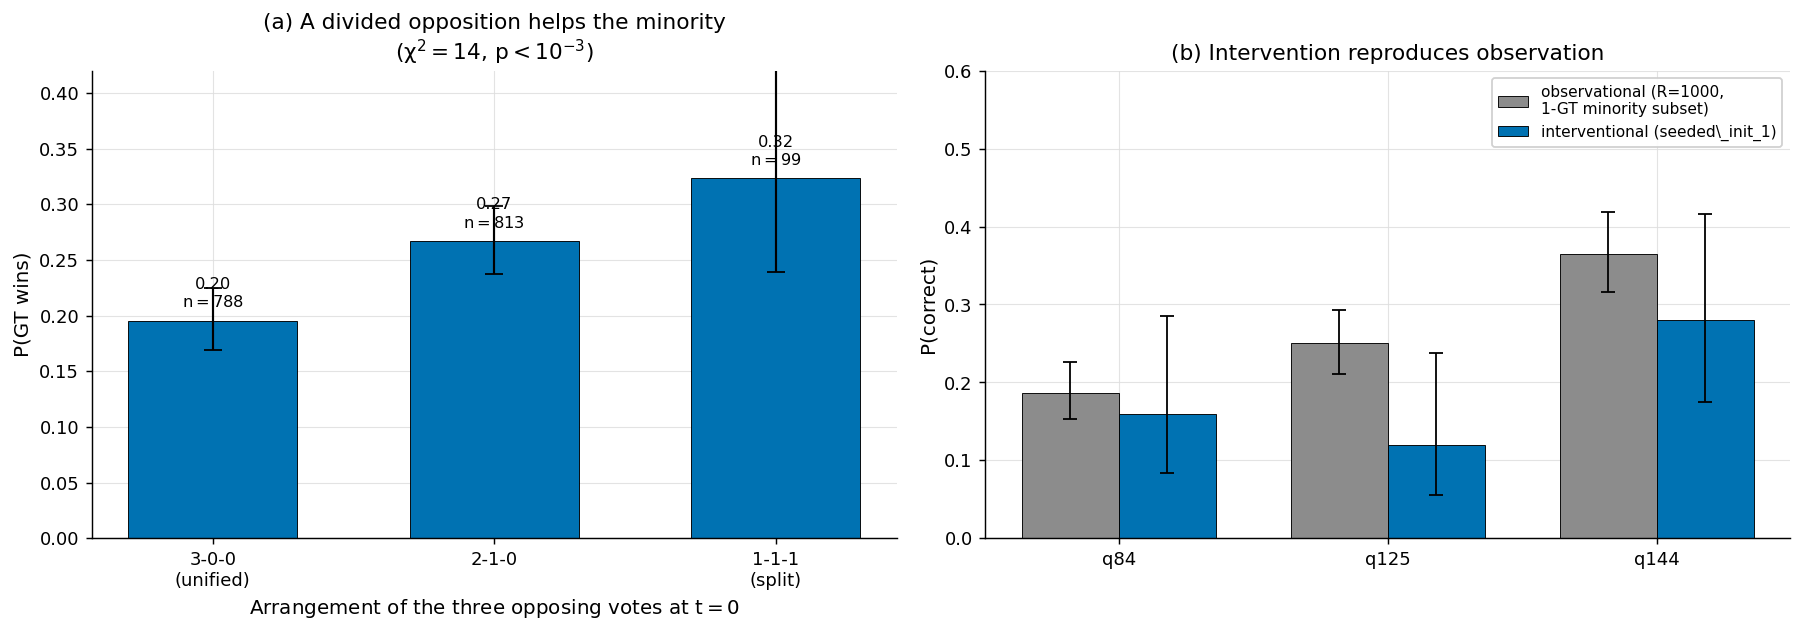

saved fig6_seeded_mechanism.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- (a) win rate by opposition concentration ---
ax = axes[0]
blocs = [3, 2, 1]
labels = ['3-0-0\n(unified)', '2-1-0', '1-1-1\n(split)']
accs, los, his, ns = [], [], [], []
for b in blocs:
    g = df1[df1['opp_top_bloc'] == b]
    k, n = g['correct'].sum(), len(g)
    accs.append(k/n); lo, hi = wilson_ci(k, n)
    los.append(lo); his.append(hi); ns.append(n)
xb = np.arange(len(blocs))
bars = ax.bar(xb, accs, color=C1, width=0.6, edgecolor='k', lw=0.5)
ax.errorbar(xb, accs, yerr=[np.array(accs)-np.array(los), np.array(his)-np.array(accs)],
            fmt='none', color='k', capsize=5, lw=1.2)
for x, a, n in zip(xb, accs, ns):
    ax.text(x, a+0.012, f'{a:.2f}\n$n={n}$', ha='center', fontsize=9)
ax.set_xticks(xb); ax.set_xticklabels(labels)
ax.set_ylabel('P(GT wins)'); ax.set_ylim(0, 0.42)
ax.set_xlabel('Arrangement of the three opposing votes at $t=0$')
ax.set_title(f'(a) A divided opposition helps the minority\n($\\chi^2={chi2d:.0f}$, $p<10^{{-3}}$)')

# --- (b) observational vs interventional ---
ax = axes[1]
xv = np.arange(len(VAL)); w = 0.36
obs_vals  = [r[1] for r in val_rows]
seed_vals = [r[3] for r in val_rows]
obs_ci  = [wilson_ci(int(r[1]*r[2]), r[2]) for r in val_rows]
seed_ci = [wilson_ci(int(r[3]*50), 50) for r in val_rows]
b1 = ax.bar(xv-w/2, obs_vals, w, color='#8c8c8c', edgecolor='k', lw=0.5,
            label='observational (R=1000,\n1-GT minority subset)')
b2 = ax.bar(xv+w/2, seed_vals, w, color=C1, edgecolor='k', lw=0.5,
            label='interventional (seeded\\_init_1)')
ax.errorbar(xv-w/2, obs_vals, yerr=[[o-c[0] for o,c in zip(obs_vals,obs_ci)],
                                    [c[1]-o for o,c in zip(obs_vals,obs_ci)]],
            fmt='none', color='k', capsize=4, lw=1.0)
ax.errorbar(xv+w/2, seed_vals, yerr=[[o-c[0] for o,c in zip(seed_vals,seed_ci)],
                                     [c[1]-o for o,c in zip(seed_vals,seed_ci)]],
            fmt='none', color='k', capsize=4, lw=1.0)
ax.set_xticks(xv); ax.set_xticklabels([f'q{q}' for q in VAL])
ax.set_ylabel('P(correct)'); ax.set_ylim(0, 0.6)
ax.set_title('(b) Intervention reproduces observation')
ax.legend(fontsize=8.5)

plt.tight_layout()
fig.savefig(EXPORT / 'fig6_seeded_mechanism.png')
plt.show()
print('saved fig6_seeded_mechanism.png')

## 4. Is de-novo recovery bounded by task difficulty?

Each task carries a fixed pool of 200 independent single-agent responses (identical
across both conditions); the initial votes are sampled from it. The correct fraction
of that pool, $\mathrm{acc}_1 = n_\text{correct}/200$, is the task's single-agent
accuracy and a clean, debate-independent measure of difficulty. It matches the
natural $t=0$ per-agent accuracy in the separate $R=1000$ runs almost exactly
(q84 0.295 vs 0.280, q125 0.280 vs 0.261, q144 0.390 vs 0.398), confirming it is a
faithful difficulty index rather than an artifact of the seeding procedure. We ask
whether the system's ability to recover the ground truth de novo (init_0) depends on
this difficulty.


In [ ]:
base = np.array([d0[q]['n_correct_pool'] / (d0[q]['n_correct_pool'] + d0[q]['n_wrong_pool'])
                 for q in COMMON])
rec      = a_per_task[0].reindex(COMMON).values
rec_runs = df0.groupby('qid')['correct'].sum().reindex(COMMON).values

rs_d, ps_d = spearmanr(base, rec)
rp_d, pp_d = pearsonr(base, rec)
print(f'recovery vs single-agent accuracy: Spearman rho={rs_d:.3f} p={ps_d:.4f}  '
      f'Pearson r={rp_d:.3f} p={pp_d:.4f}')

order = np.argsort(base); n = len(order)
qlabels = ['Q1 hardest', 'Q2', 'Q3', 'Q4 easiest']
quarts = [order[i*n//4:(i+1)*n//4] for i in range(4)]
print('\nrecovery by single-agent-accuracy quartile:')
for lab, idx in zip(qlabels, quarts):
    print(f'  {lab:12s}: base_acc={base[idx].mean():.3f}  '
          f'mean recovery={rec[idx].mean():.4f}  recovered={int(rec_runs[idx].sum())}/{len(idx)*50}')

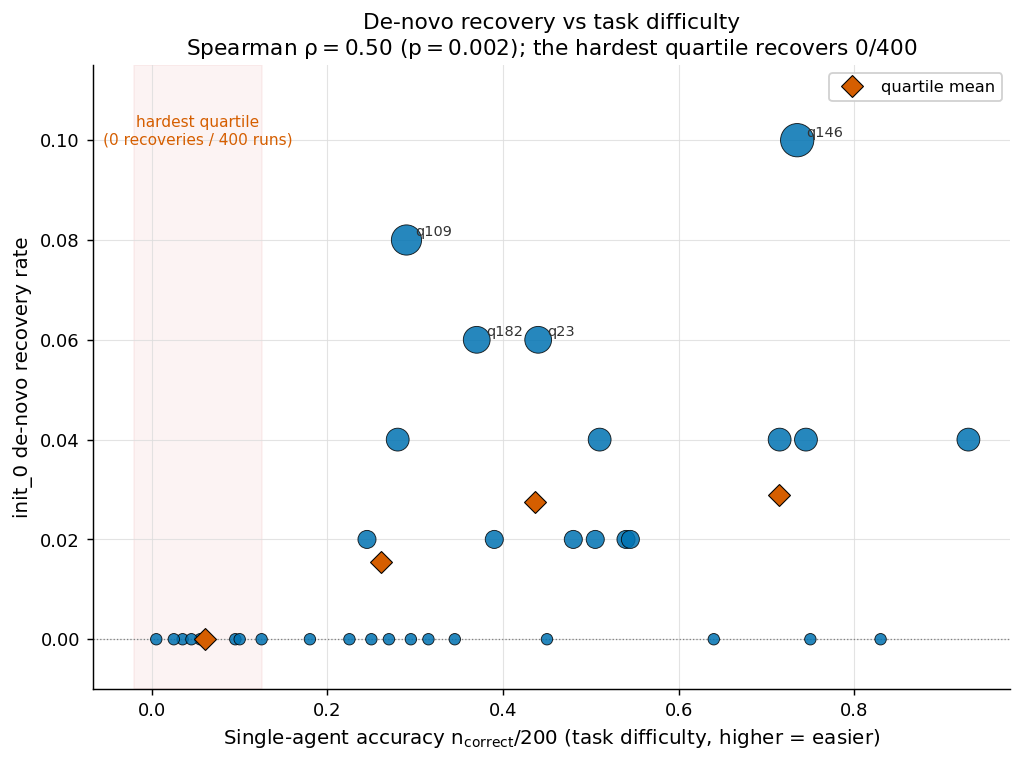

saved fig7_recovery_difficulty.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

sizes = 40 + rec_runs * 60
ax.scatter(base, rec, s=sizes, color=C1, edgecolor='k', lw=0.5, alpha=0.85, zorder=3)
# label only the notable high-recovery tasks (hard-task cluster sits on y=0, self-evident)
for q, x, y, k in zip(COMMON, base, rec, rec_runs):
    if y > 0.055:
        ax.annotate(f'q{q}', (x, y), fontsize=8, xytext=(5, 2),
                    textcoords='offset points', color='#333333')
# LOWESS-free simple trend: bin means
order = np.argsort(base); n = len(order)
for i in range(4):
    idx = order[i*n//4:(i+1)*n//4]
    ax.plot(base[idx].mean(), rec[idx].mean(), 'D', color=CACC, ms=9,
            zorder=4, mec='k', mew=0.6)
ax.plot([], [], 'D', color=CACC, ms=9, mec='k', mew=0.6, label='quartile mean')
ax.axhline(0, color='gray', lw=0.7, ls=':')
q1_hi = base[order[:n//4]].max()
ax.axvspan(-0.02, q1_hi, color='#D65F5F', alpha=0.07, zorder=0)
ax.text((q1_hi-0.02)/2, max(rec)*1.05, 'hardest quartile\n(0 recoveries / 400 runs)',
        ha='center', va='top', fontsize=8.5, color=CACC)
ax.set_xlabel('Single-agent accuracy $n_\\text{correct}/200$ (task difficulty, higher = easier)')
ax.set_ylabel('init_0 de-novo recovery rate')
ax.set_title(f'De-novo recovery vs task difficulty\n'
             f'Spearman $\\rho={rs_d:.2f}$ ($p={ps_d:.3f}$); the hardest quartile recovers 0/{len(quarts[0])*50}')
ax.legend(fontsize=9)
ax.set_ylim(-0.01, max(rec)*1.15)

plt.tight_layout()
fig.savefig(EXPORT / 'fig7_recovery_difficulty.png')
plt.show()
print('saved fig7_recovery_difficulty.png')

## 5. Summary statistics for LaTeX

In [ ]:
print('=== headline numbers for LaTeX ===\n')
for i, (k, n, a) in enumerate(zip(ks, ns, accs_pooled)):
    ci = wilson_ci(k, n)
    print(f'init_{i} pooled acc = {a*100:.1f}% ({k}/{n})  CI=({ci[0]*100:.1f}%, {ci[1]*100:.1f}%)')

print()
for i in range(1, 4):
    ct = np.array([[ks[i], ns[i]-ks[i]], [ks[0], ns[0]-ks[0]]])
    chi2, p, _, _ = chi2_contingency(ct)
    print(f'init_{i} vs init_0: lift={accs_pooled[i]/accs_pooled[0]:.1f}x  chi2={chi2:.0f}  p={p:.1e}')

print()
w01, pw01 = wilcoxon(a_per_task[1].values, a_per_task[0].values)
print(f'paired Wilcoxon init_1 vs init_0: {(a_per_task[1].values>a_per_task[0].values).sum()}/{len(COMMON)} tasks  p={pw01:.1e}')

print()
for i in [1, 2, 3]:
    cap, conv, part = fate_stats[i]
    tot = len(dfs[i])
    print(f'init_{i} fate: converts={conv/tot:.1%}  capitulates={cap/tot:.1%}  partial={part}')

print(f'\ninit_1 mean overtake round: {np.mean(overtake):.2f}')
print(f'init_0 de-novo runs: {len(recov)}  mean first-appearance round: {np.mean(recov):.2f}')
print(f'init_0 tasks with >=1 recovery: {n_denovo_tasks}/{len(COMMON)}')
print(f'spearman(pool, init_0 acc): rs={rs:.3f} p={ps:.1e}')
print()
print('mean rounds:', '  '.join(f'init_{i}={d["rounds"].mean():.2f}' for i, d in enumerate(dfs)))